# Multimodal AutoML LOOCV — SC + FC + MSN  [SC–FC coupling에 MSN strength를 붙임 · pass]

세 모달리티(SC, FC, MSN)를 한 예측에 쓰는 방법 다섯 가지 중 **방법 E**다. 방법마다 노트북을 따로 만들었다.
뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize)는 `multimodal_sc_fc84/`, `multimodal_msn_fc68/` 노트북과 같다.

## 이 노트북의 방법

SC와 FC는 둘의 **관계(SC–FC coupling)**로 넣고, MSN은 strength로 넣는다. 세 모달리티가 한 번씩만 들어간다.
영역별 SC–FC coupling을 PCA 3으로 줄이고, MSN strength PCA 3과 붙여 6개를 만든다.

## 데이터 / 표본

- `../sc_dk84/sc_strength_84_pass.csv` (SC strength 84, 모델에 넣을 때 log(1 + count)), `../fc_strength_68_16.csv` (FC strength 84), `../msn_strength_68.csv` (MSN strength, 피질 68)
- `../sc_dk84/sc_full_84x84_pass.csv`, `../fc_full_84x84_edited.csv` (edge 3486개씩) → SC–FC coupling 계산에만 사용
- SC 45명 ∩ FC 44명 ∩ MSN 45명 = **공통 44명** (sub-001은 FC 없음). 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.
- nuisance (fold 안 train에서만 fit): SC와 MSN은 age, sex, eTIV / FC는 age, sex, mean_fd / coupling은 age, sex, eTIV, mean_fd

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 내용 |
|---|---|
| `Clinical_ONLY` | 뇌 피처 없음 |
| `SCFC_Coup_PCA3` | 영역별 SC–FC coupling(Spearman) → PCA 3. `multimodal_sc_fc84/`의 `Coupling_S_PCA3`과 같은 계산 |
| `MSN_PCA3` | MSN strength 68 → PCA 3 |
| `Tri_SCFCcoup_MSN` | **SC–FC coupling PCA3 + MSN PCA3 (6개)** |

PCA 성분 수 3은 모든 블록에서 같고, 기존 노트북과 맞춘 값이다.

## 연결 기준: **pass** — streamline이 두 영역을 모두 지나가면 연결로 센다 (DSI Studio 기본값). **주 분석**

SC는 "무엇을 연결로 세느냐"에 따라 값이 크게 달라진다. 같은 사람들로 구한 영역별 coupling의 pass와 end 사이
상관이 0.525였다. 그래서 같은 분석을 두 기준으로 따로 만들었고(`..._pass.ipynb`, `..._end.ipynb`),
**주 분석은 pass, end는 민감도 분석**으로 결과를 보기 전에 정해 두었다. 어느 쪽이 좋게 나오든 둘 다 보고한다.

## 읽을 때 주의

- **결과를 본 뒤에 정한 조합이다.** SC + FC(end)와 MSN–FC ROI coupling이 좋게 나온 것을 확인한 다음 만들었다.
  방법 다섯 가지를 미리 정해 두고 pass, end를 전부 보고한다. 탐색적 결과로 읽는다.
- 잔차화 직전에 nuisance를 train 기준으로 표준화한다. 잔차는 수학적으로 같고, eTIV(백만 단위)로 인한 계산 정밀도 문제를 막는다.
- 기존 노트북과 같은 계산인 열은 값이 같아야 한다 (확인용).

### 같은 폴더의 변형 (각각 `_pass`, `_end`)

| 방법 | 파일 | 내용 |
|---|---|---|
| A | `..._SC_FC84_MSN68_PCA3` | 따로 PCA 3씩 줄여서 붙임 (9개) |
| B | `..._SC_FC84_MSN68_joint_PCA3` | 셋을 먼저 붙이고 PCA 3 한 번 (3개) |
| C | `..._SC_FC84_PCA3_plus_MSNFC_coupling_ROI` | SC PCA3 + FC PCA3 + MSN–FC coupling ROI 4개 (10개) |
| D | `..._SC_FC84_PCA3_MSNFC_coupling_ROI_latefusion` | C의 두 재료를 따로 학습하고 예측값을 평균 |
| E | `..._SCFC_coupling_PCA3_plus_MSN68_PCA3` | SC–FC coupling PCA3 + MSN PCA3 (6개) |


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (SC 84 + FC 84 + MSN 68, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'            # 데이터 CSV는 TMS 루트와 sc_dk84/ 에 있다
SC_RULE = 'pass'           # 'pass'(지나가면 셈, 주 분석) 또는 'end'(끝점 기준, 민감도 분석)

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

sc_s  = load(f'sc_dk84/sc_strength_84_{SC_RULE}.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s  = load('fc_strength_68_16.csv')                    # 앞 7열: ... mean_fd  (84개 영역)
msn_s = load('msn_strength_68.csv')                      # 앞 7열: ... eTIV     (피질 68개)

# --- ROI 매칭 확인 ---
ROIS = [c[:-len('_sc')] for c in sc_s.columns[7:]]         # 84개 (피질 68 + 피질하 16)
assert len(ROIS) == 84 and [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'SC/FC ROI 순서 불일치'
ROIS68 = [c[:-len('_msn')] for c in msn_s.columns[7:]]     # MSN은 피질 68개
assert len(ROIS68) == 68 and set(ROIS68) <= set(ROIS), 'MSN ROI가 84개 목록에 없음'

# --- rid inner join: SC 45명 ∩ FC 44명 ∩ MSN 45명 = 공통 44명 (sub-001은 FC 없음) ---
df = (sc_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
          .merge(msn_s[['rid'] + list(msn_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# --- 임상 변수와 eTIV는 세 파일 모두 structural CSV에서 왔으므로 같아야 한다 ---
for other, cols in [(fc_s, ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']),
                    (msn_s, ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex', 'eTIV'])]:
    o = other.set_index('rid').loc[df['rid']]
    for c in cols:
        assert np.allclose(o[c].values, df[c].values), c

# ---- SC–FC coupling, 영역별 (multimodal_sc_fc84/ 의 coupling_PCA3_spearman 노트북과 같은 계산) ----
sc_e = load(f'sc_dk84/sc_full_84x84_{SC_RULE}.csv')
fc_e = load('fc_full_84x84_edited.csv')
sc_edge_cols, fc_edge_cols = list(sc_e.columns[7:]), list(fc_e.columns[7:])
assert [c[:-len('_sc')] for c in sc_edge_cols] == fc_edge_cols, 'edge 순서 불일치'
E_sc = sc_e.set_index('rid').loc[df['rid'], sc_edge_cols].values.astype(float)   # (44, 3486) streamline 개수
E_fc = fc_e.set_index('rid').loc[df['rid'], fc_edge_cols].values                 # (44, 3486) Fisher z
IU84 = np.triu_indices(84, k=1)
MIN_PARTNERS = 3          # Spearman이 +1/-1 이외의 값을 낼 수 있는 최소 개수

def to_matrix84(edge_row):
    M = np.zeros((84, 84))
    M[IU84] = edge_row
    return M + M.T

def coupling_sc_fc(sc_edges, fc_edges):
    """ROI i: SC i행과 FC i행의 Spearman rho. SC가 0이 아닌 partner만 쓴다 (Baum 2020, Qian 2026).

    partner가 MIN_PARTNERS 미만이거나 SC 값이 전부 같아 순위를 매길 수 없으면 NaN을 돌려준다.
    """
    S, F = to_matrix84(sc_edges), to_matrix84(fc_edges)
    out = np.full(84, np.nan)
    for i in range(84):
        k = S[i] > 0
        if k.sum() >= MIN_PARTNERS and np.ptp(S[i, k]) > 0:
            out[i] = spearmanr(S[i, k], F[i, k]).statistic
    return out

C_scfc = np.array([coupling_sc_fc(E_sc[k], E_fc[k]) for k in range(len(df))])    # (44, 84)
keep = ~np.isnan(C_scfc).any(axis=0)       # 한 명이라도 계산할 수 없는 영역은 뺀다. 없는 값을 채워 넣지 않는다.
X_scfc = C_scfc[:, keep]
dropped = [(r, int(np.isnan(C_scfc[:, j]).sum())) for j, r in enumerate(ROIS) if not keep[j]]

X_sc       = np.log1p(df[[f'{r}_sc' for r in ROIS]].values)   # SC를 피처로 쓸 때는 log(1 + count) (Tong 2026)
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_msn      = df[[f'{r}_msn' for r in ROIS68]].values
X_nuis_sc  = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_msn = df[['age', 'sex', 'eTIV']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values     # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'연결 기준 {SC_RULE}  |  n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'SC strength {X_sc.shape[1]} | FC strength {X_fc.shape[1]} | MSN strength {X_msn.shape[1]}')
print(f'SC–FC coupling {X_scfc.shape[1]}개 영역 | 제외한 영역 {len(dropped)}개 (영역, 계산 불가 인원): {dropped}')
print(f'  평균 {X_scfc.mean():+.3f} (SD {X_scfc.std():.3f})')

연결 기준 pass  |  n = 44  |  Active 25 / Sham 19
SC strength 84 | FC strength 84 | MSN strength 68
SC–FC coupling 84개 영역 | 제외한 영역 0개 (영역, 계산 불가 인원): []
  평균 +0.254 (SD 0.187)


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # 모든 블록에서 같은 값 (기존 노트북과 동일)

DATA_TYPES = ['Clinical_ONLY', 'SCFC_Coup_PCA3', 'MSN_PCA3', 'Tri_SCFCcoup_MSN']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 블록별 nuisance residualization → scale → (PCA) → stack → StandardScaler → 모델
#    SC–FC coupling(영역별)도 같은 방식으로 PCA(3)로 줄인다
#    ※ 4 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_only(X, N, tr, te):
    """nuisance 회귀 잔차. nuisance 표준화와 회귀 모두 train에서만 fit한다.

    nuisance를 먼저 표준화한다. 잔차는 수학적으로 같지만, eTIV(백만 단위)가 그대로 들어가면
    계산 정밀도 문제가 생길 수 있다 (multimodal_sc_fc84/ 노트북과 동일).
    """
    nz = StandardScaler().fit(N[tr])
    reg = LinearRegression().fit(nz.transform(N[tr]), X[tr])
    return X[tr] - reg.predict(nz.transform(N[tr])), X[te] - reg.predict(nz.transform(N[te]))

def resid_scale(X, N, tr, te):
    """resid_only → 표준화. 전부 train에서만 fit."""
    X_tr, X_te = resid_only(X, N, tr, te)
    sc = StandardScaler().fit(X_tr)
    return sc.transform(X_tr), sc.transform(X_te)

def fit_pca(Z_tr, Z_te):
    """PCA(N_PCA)를 train에서만 fit."""
    pca = PCA(n_components=N_PCA, random_state=42).fit(Z_tr)
    return pca.transform(Z_tr), pca.transform(Z_te), pca

loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_sc)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Zm_tr, Zm_te = resid_scale(X_msn, X_nuis_msn, tr, te)
    Xm_tr, Xm_te, _ = fit_pca(Zm_tr, Zm_te)
    Zp_tr, Zp_te = resid_scale(X_scfc, X_nuis_cp, tr, te)
    Xp_tr, Xp_te, _ = fit_pca(Zp_tr, Zp_te)
    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'SCFC_Coup_PCA3':  (np.hstack([Xp_tr, Xc_tr]),               np.hstack([Xp_te, Xc_te])),
        'MSN_PCA3':        (np.hstack([Xm_tr, Xc_tr]),               np.hstack([Xm_te, Xc_te])),
        'Tri_SCFCcoup_MSN': (np.hstack([Xp_tr, Xm_tr, Xc_tr]),       np.hstack([Xp_te, Xm_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")

Starting LOOCV: 6 models x 4 datasets x 44 folds ...





LOOCV done.


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Tri_vs_Coup':    ('SCFC_Coup_PCA3', 'Tri_SCFCcoup_MSN'),
    'd_Tri_vs_MSN':     ('MSN_PCA3', 'Tri_SCFCcoup_MSN'),
    'd_Tri_vs_Clin':    ('Clinical_ONLY', 'Tri_SCFCcoup_MSN'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,SCFC_Coup_PCA3,MSN_PCA3,Tri_SCFCcoup_MSN,d_Tri_vs_Coup,d_Tri_vs_MSN,d_Tri_vs_Clin
Model,,,,,,,
LinearRegression,1.997,1.853,2.044,1.881,-0.029,0.163,0.116
ElasticNet,1.996,1.877,2.014,1.884,-0.008,0.130,0.112
SVR_Linear,2.041,1.823,2.004,2.000,-0.177,0.004,0.041
SVR_RBF,2.208,1.911,2.020,2.101,-0.190,-0.081,0.107
RandomForest,2.201,2.160,2.297,2.229,-0.069,0.068,-0.029
XGBoost,2.235,2.095,2.286,2.241,-0.146,0.044,-0.006



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Tri_vs_Coup     0/6   (선형·커널 4개 중 0)
  d_Tri_vs_MSN      5/6   (선형·커널 4개 중 3)
  d_Tri_vs_Clin     4/6   (선형·커널 4개 중 4)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,SCFC_Coup_PCA3,SVR_Linear,1.8231,0.3475,0.5935,0.0000
1,SCFC_Coup_PCA3,LinearRegression,1.8526,0.3261,0.5751,0.0000
2,SCFC_Coup_PCA3,ElasticNet,1.8766,0.3086,0.5598,0.0001
3,Tri_SCFCcoup_MSN,LinearRegression,1.8814,0.3050,0.5657,0.0001
4,Tri_SCFCcoup_MSN,ElasticNet,1.8843,0.3028,0.5521,0.0001
5,SCFC_Coup_PCA3,SVR_RBF,1.9114,0.2827,0.5539,0.0001
6,Clinical_ONLY,ElasticNet,1.9962,0.2176,0.4778,0.0010
7,Clinical_ONLY,LinearRegression,1.9973,0.2167,0.4784,0.0010
8,Tri_SCFCcoup_MSN,SVR_Linear,2.0001,0.2146,0.5154,0.0003
9,MSN_PCA3,SVR_Linear,2.0039,0.2116,0.4882,0.0008


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,SCFC_Coup_PCA3,MSN_PCA3,Tri_SCFCcoup_MSN
Model,,,,
LinearRegression,1.997,1.853,2.044,1.881
ElasticNet,1.996,1.877,2.014,1.884
SVR_Linear,2.041,1.823,2.004,2.000
SVR_RBF,2.208,1.911,2.020,2.101
RandomForest,2.201,2.160,2.297,2.229
XGBoost,2.235,2.095,2.286,2.241



===== Active  RMSE =====


Data Type,Clinical_ONLY,SCFC_Coup_PCA3,MSN_PCA3,Tri_SCFCcoup_MSN
Model,,,,
LinearRegression,2.004,1.787,2.053,1.787
ElasticNet,2.003,1.831,2.041,1.843
SVR_Linear,2.055,1.785,2.017,1.932
SVR_RBF,2.291,1.890,2.044,2.122
RandomForest,2.261,2.235,2.461,2.343
XGBoost,2.341,2.014,2.356,2.253



===== Sham  RMSE =====


Data Type,Clinical_ONLY,SCFC_Coup_PCA3,MSN_PCA3,Tri_SCFCcoup_MSN
Model,,,,
LinearRegression,1.989,1.935,2.032,1.999
ElasticNet,1.988,1.935,1.979,1.938
SVR_Linear,2.022,1.872,1.986,2.086
SVR_RBF,2.095,1.939,1.987,2.073
RandomForest,2.118,2.059,2.062,2.070
XGBoost,2.089,2.197,2.189,2.226


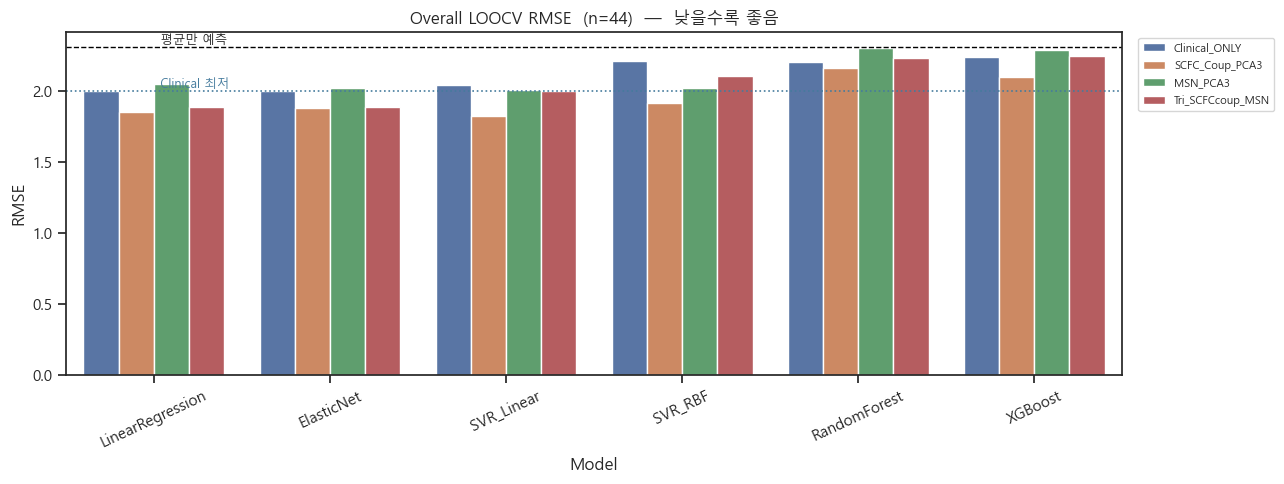

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[SCFC_Coup_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[SCFC_Coup_PCA3 / ElasticNet] 고유 4개, 최빈 82%
[SCFC_Coup_PCA3 / SVR_Linear] 고유 10개, 최빈 32%   <-- 불안정
[SCFC_Coup_PCA3 / SVR_RBF] 고유 7개, 최빈 30%   <-- 불안정
[SCFC_Coup_PCA3 / RandomForest] 고유 10개, 최빈 27%   <-- 불안정
[SCFC_Coup_PCA3 / XGBoost] 고유 12개, 최빈 25%   <-- 불안정
[MSN_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[MSN_PCA3 / ElasticNet] 고유 6개, 최빈 86%
[MSN_PCA3 / SVR_Linear] 고유 5개, 최빈 32%   <-- 불안정
[MSN_PCA3 / SVR_RBF] 고유 2개, 최빈 95%
[MSN_PCA3 / RandomForest] 고유 4개, 최빈 50%
[MSN_PCA3 / XGBoost] 고유 3개, 최빈 57%
[Tri_SCFCcoup_MSN / LinearRegression] 고유 1개, 최빈 100%
[Tri_SCFCcoup_MSN / ElasticNet] 고유 8개, 최빈 23%   <-- 불안정
[Tri_SCFCcoup_MSN / SVR_Linear] 고유 14개, 최빈 27%   <-- 불안정
[Tri_SCFCc

## 결과 읽는 법

1. **합치면 둘 다보다 나은가**: `d_Tri_vs_Coup`와 `d_Tri_vs_MSN`이 **둘 다** +여야 한다.
2. **재료의 상태**: SC–FC coupling PCA 3은 pass 기준에서 6개 모델 모두 임상 변수만 쓴 것보다 좋았고, end 기준에서는 그렇지 않았다
   (`multimodal_sc_fc84/`의 coupling_PCA3 노트북). MSN strength PCA 3은 따로 넣었을 때 임상 변수만 쓴 것을 넘지 못했다.
3. **Active와 Sham**: 5번 셀과 10번 셀에서 군별 RMSE, r, R2를 나란히 본다. 모델은 44명 전체로 학습한 것이다.
4. **연결 기준**: pass가 주 분석이다. end에서 방향이 다르면 결론이 연결 기준에 달려 있다는 뜻이고, 그렇게 적는다.
5. **하지 말 것**: 다섯 방법과 두 연결 기준 중 좋게 나온 것만 골라 보고하는 것. 전부 보고한다.


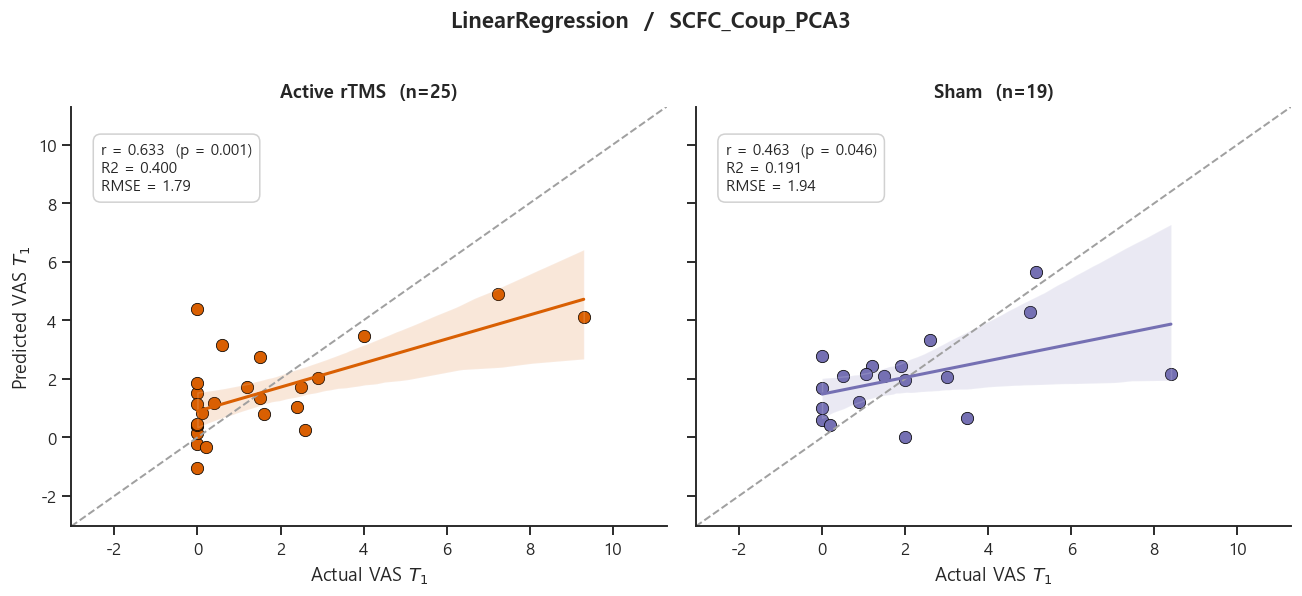

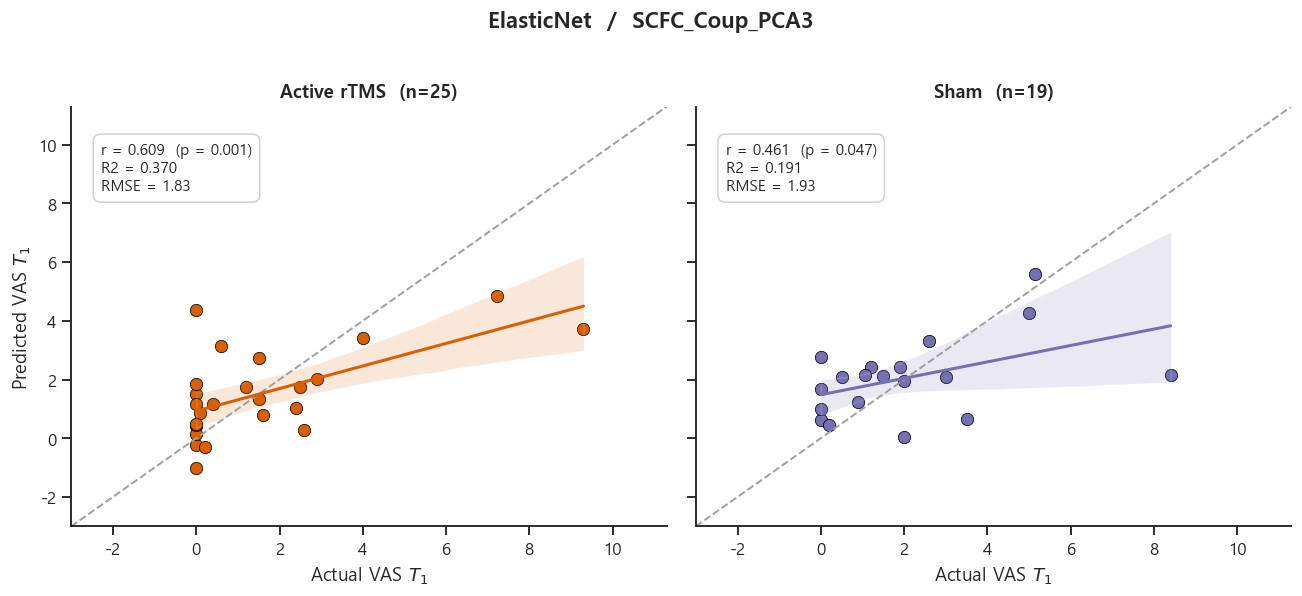

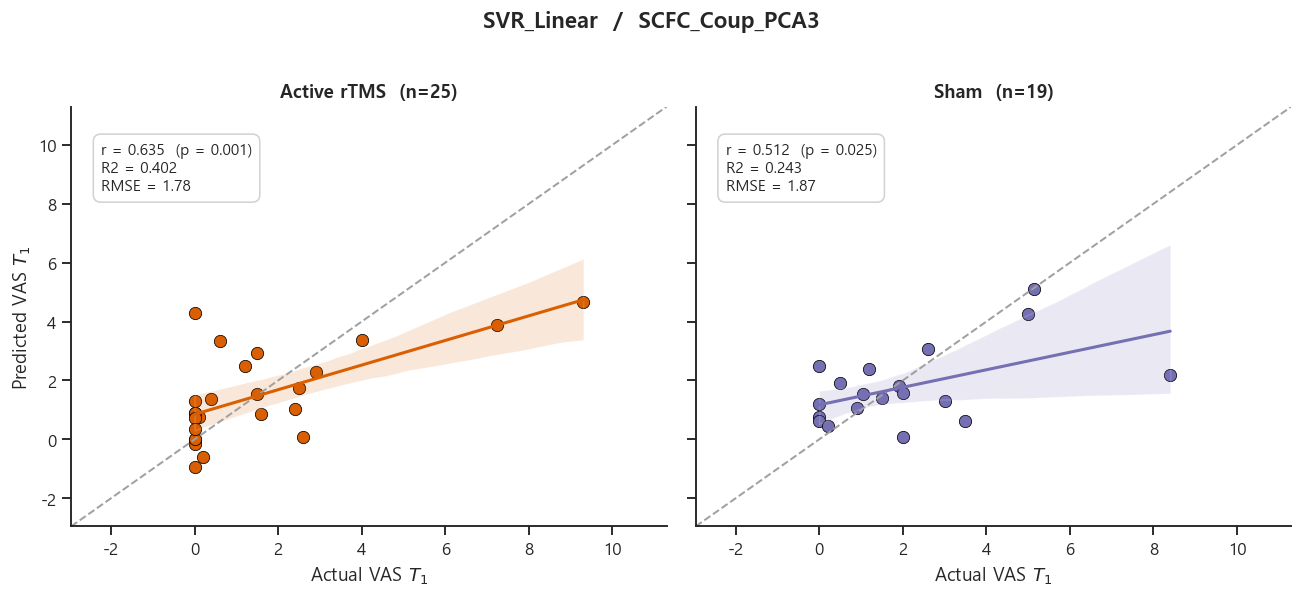

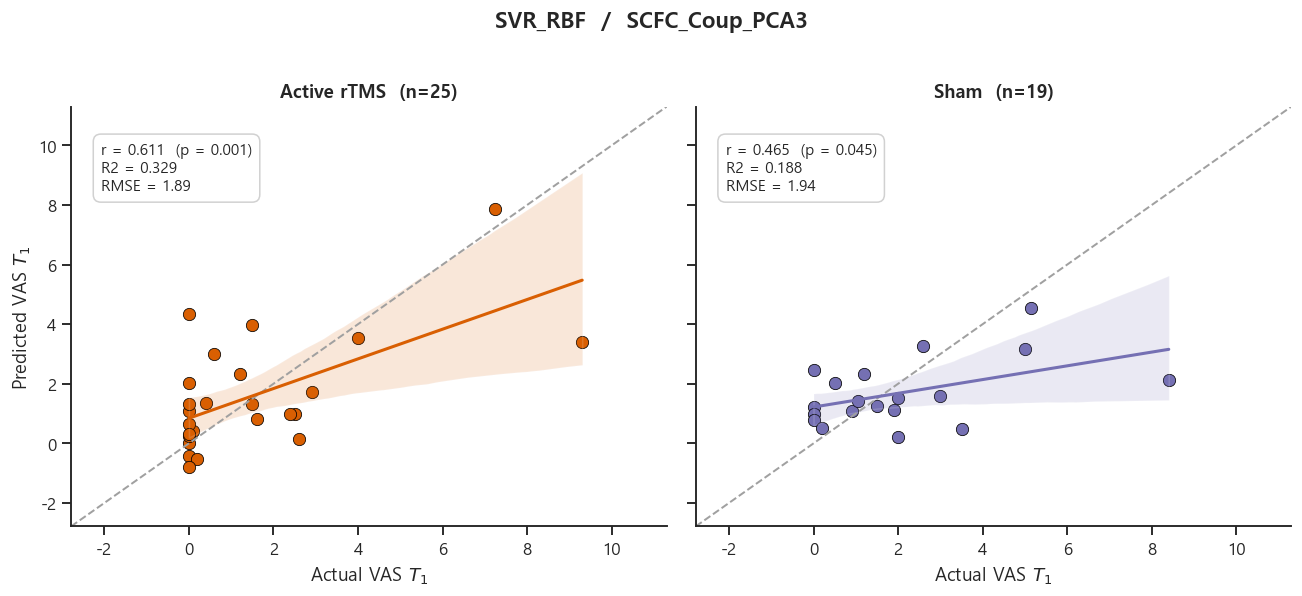

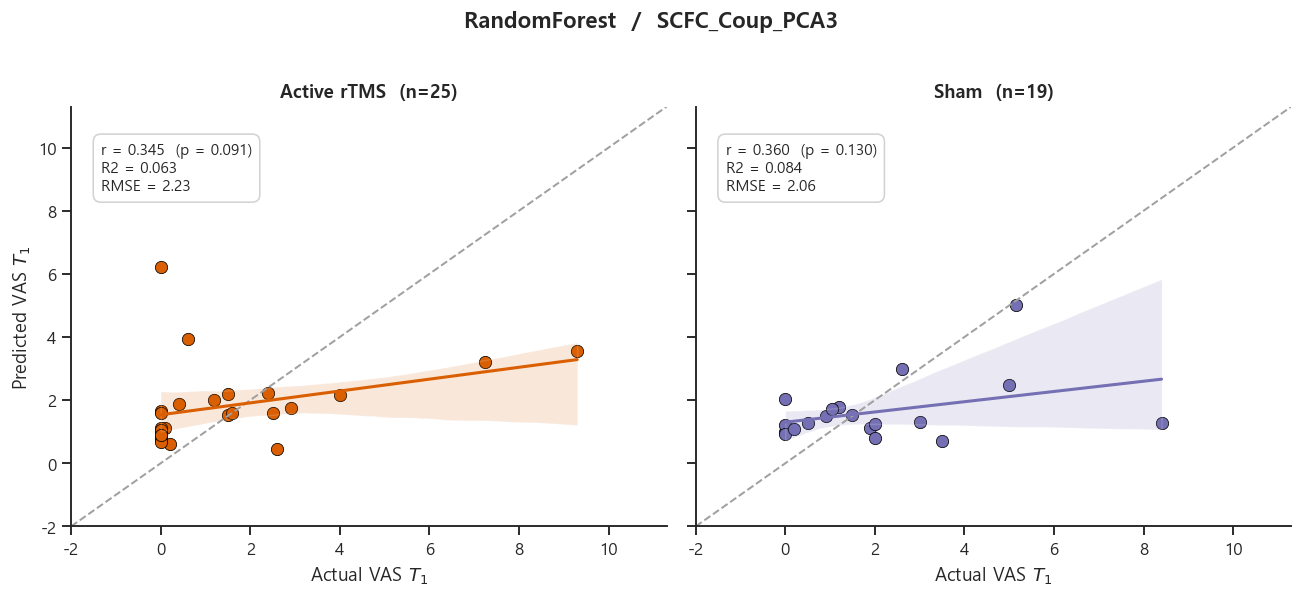

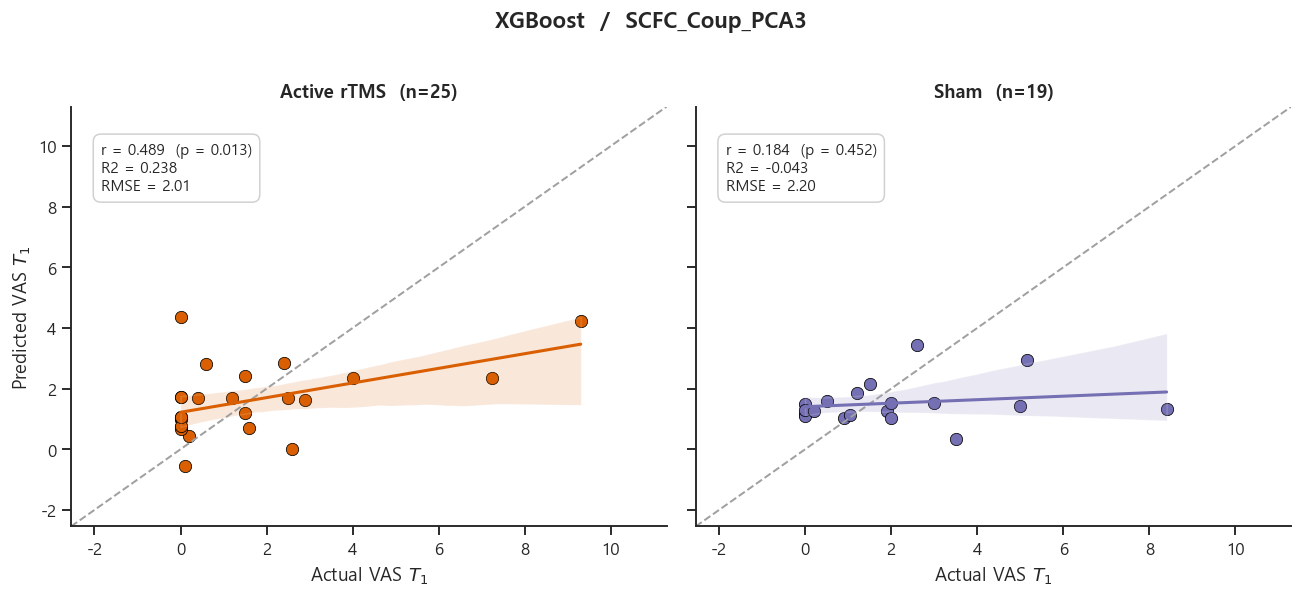

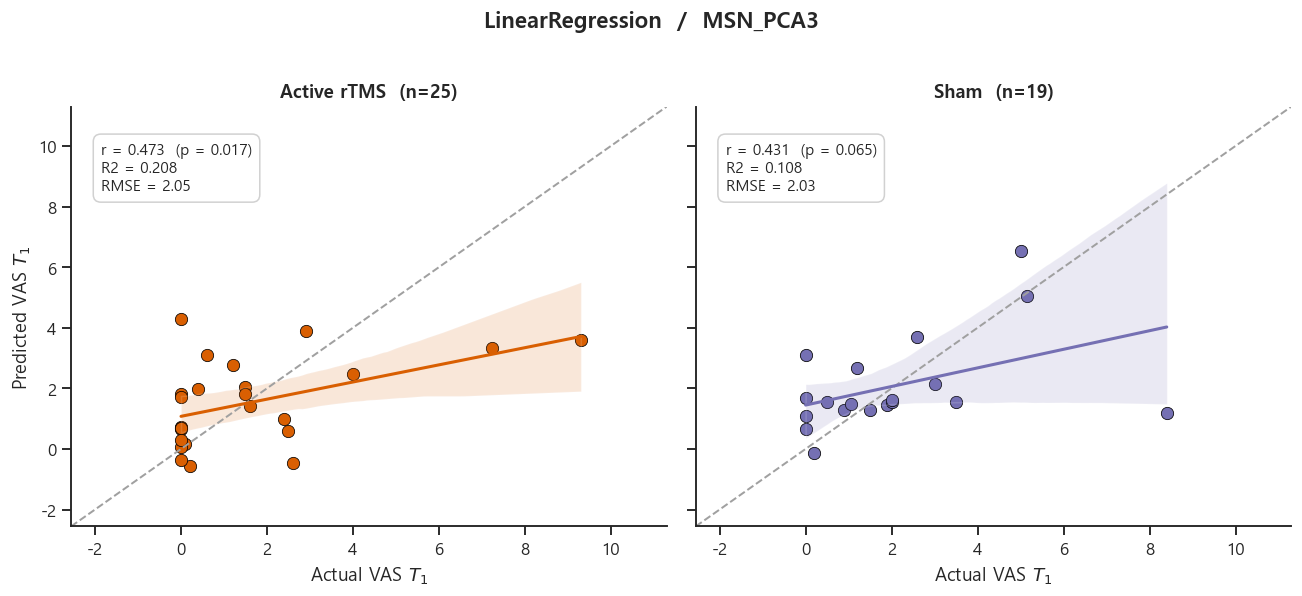

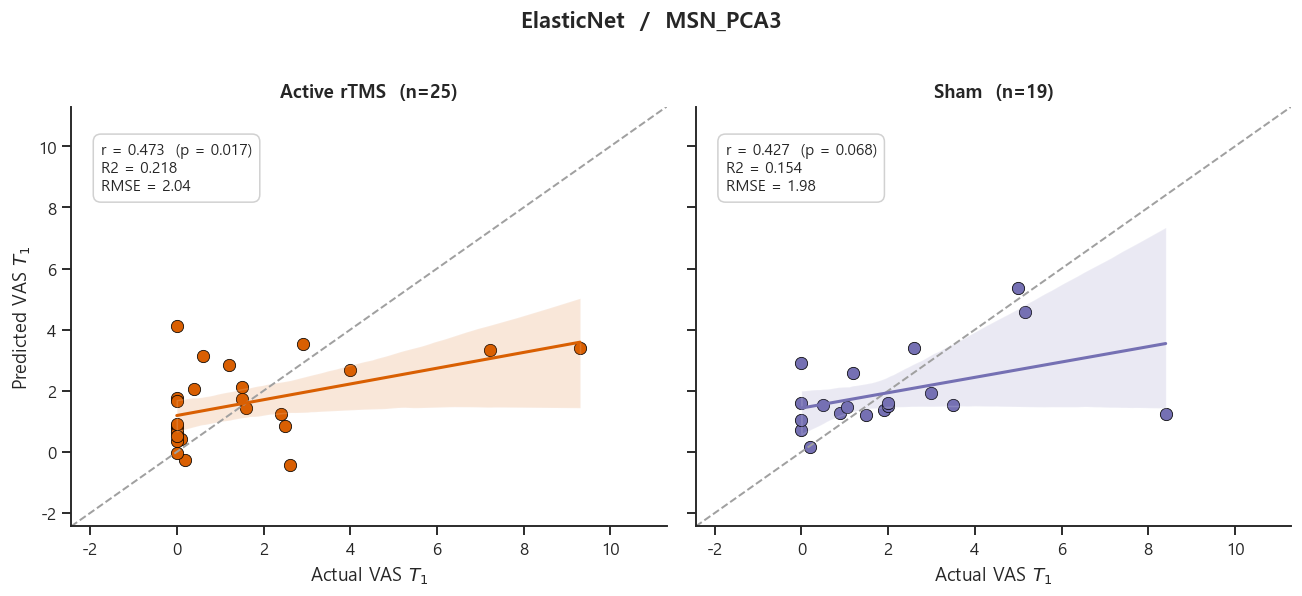

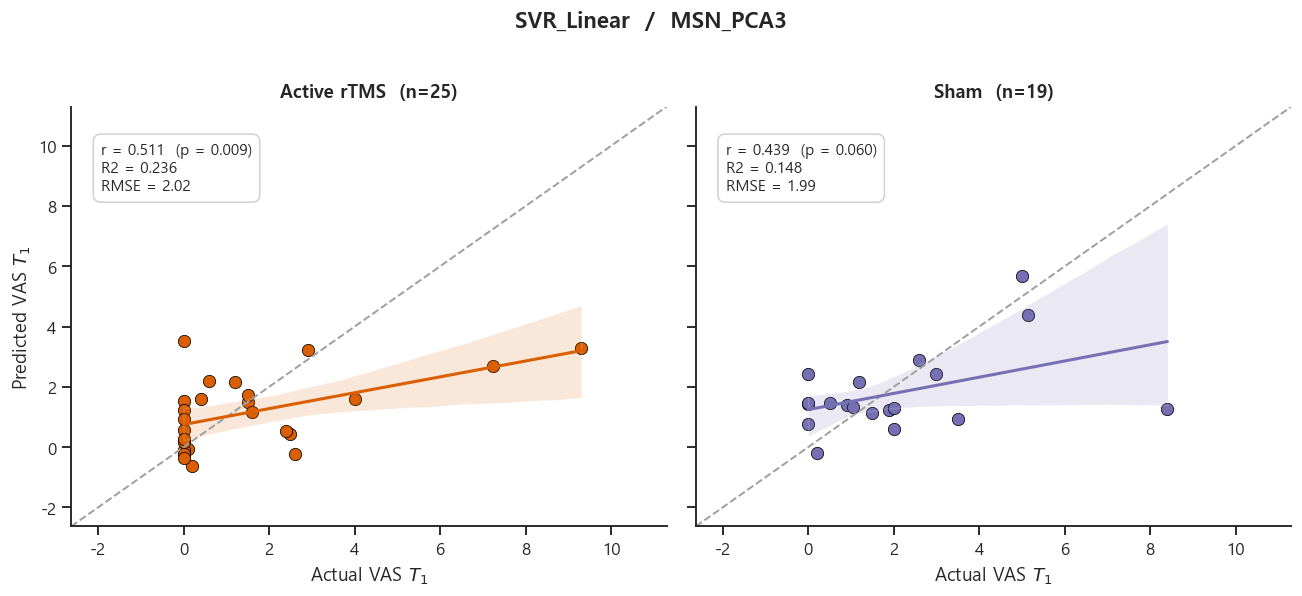

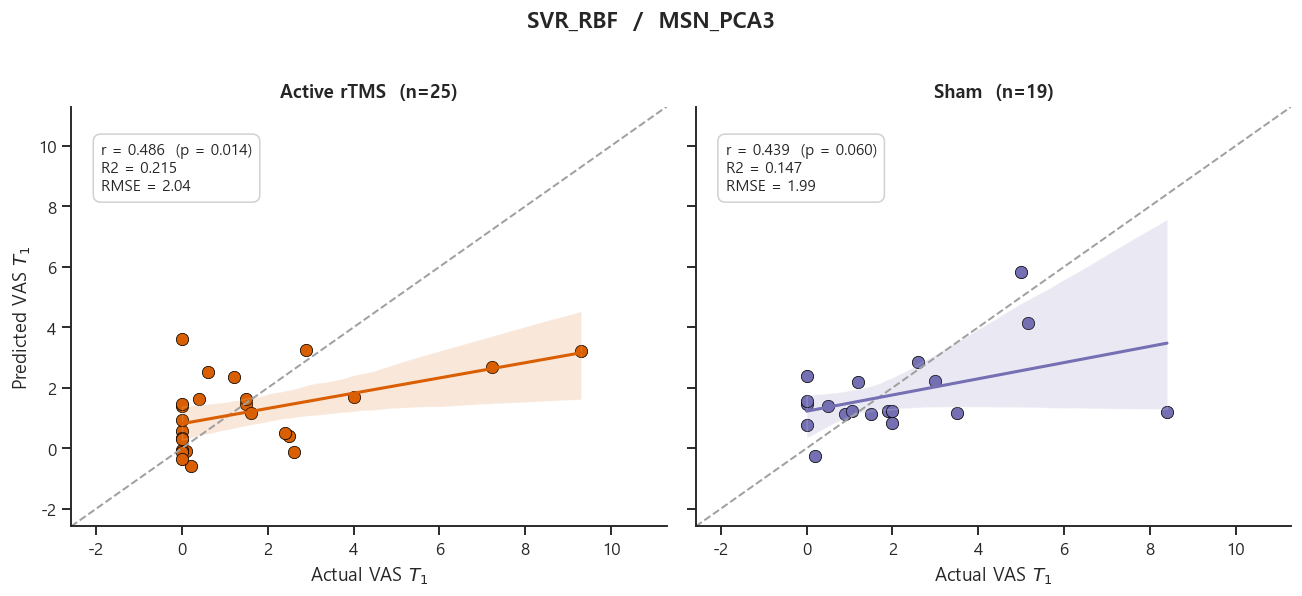

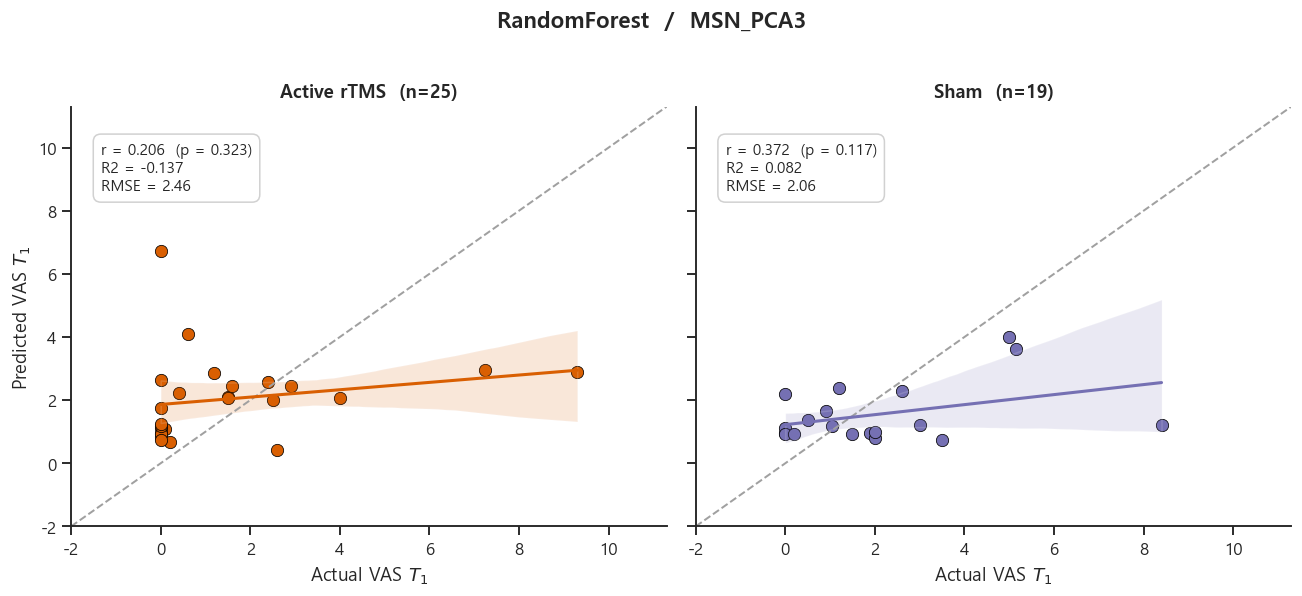

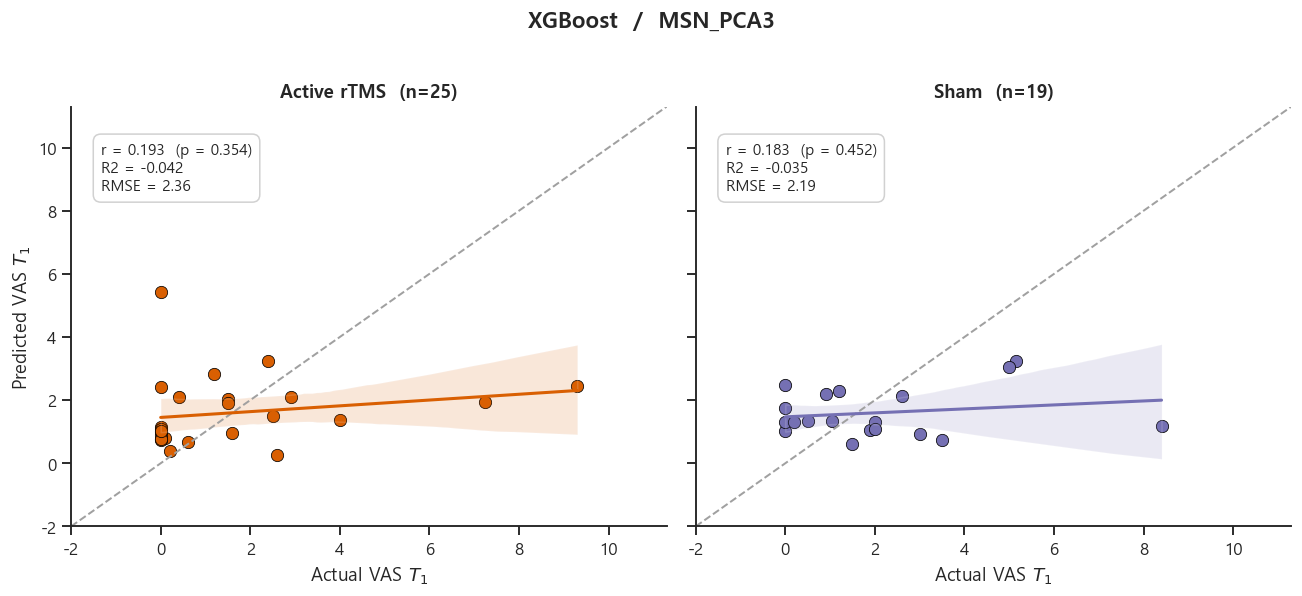

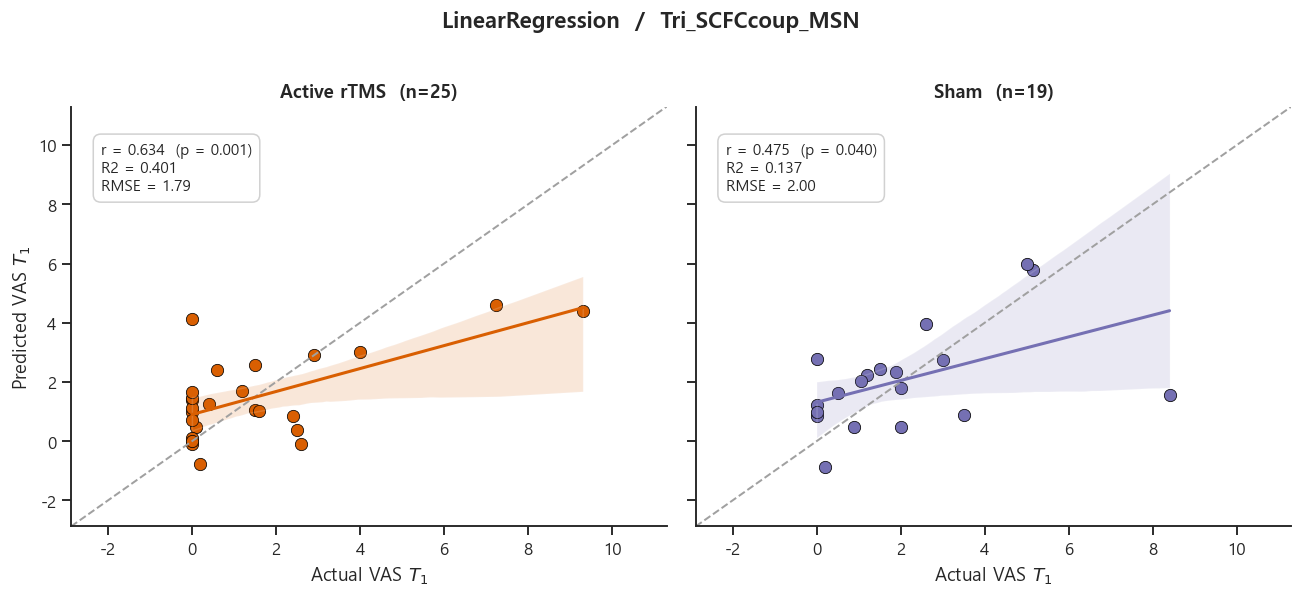

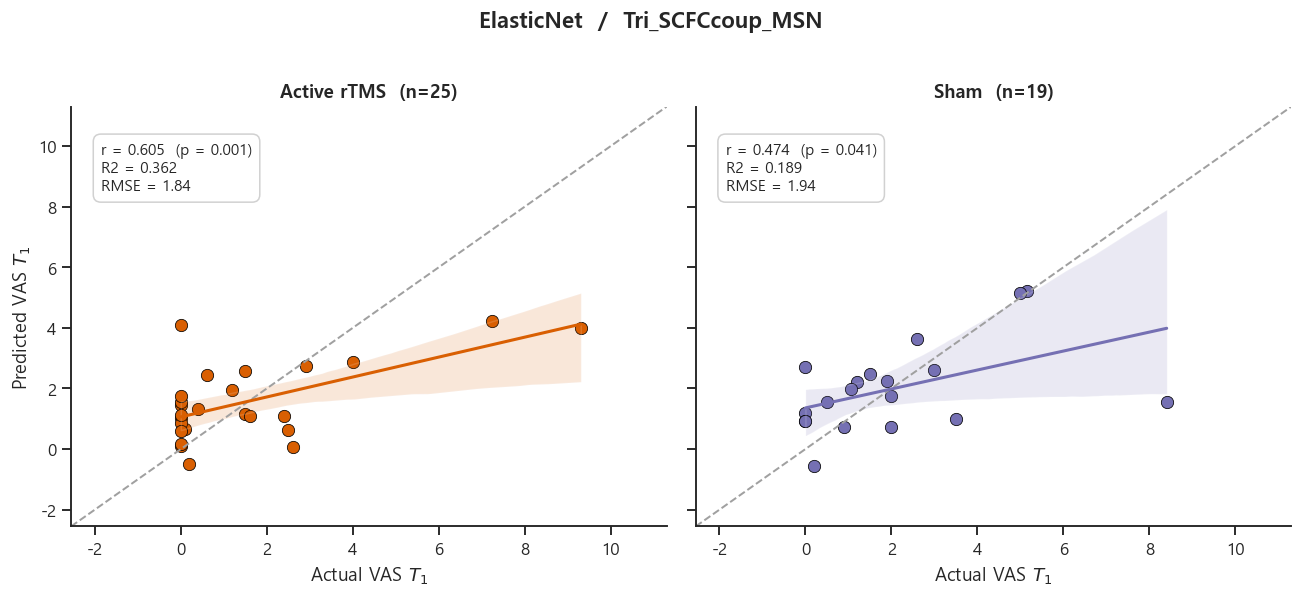

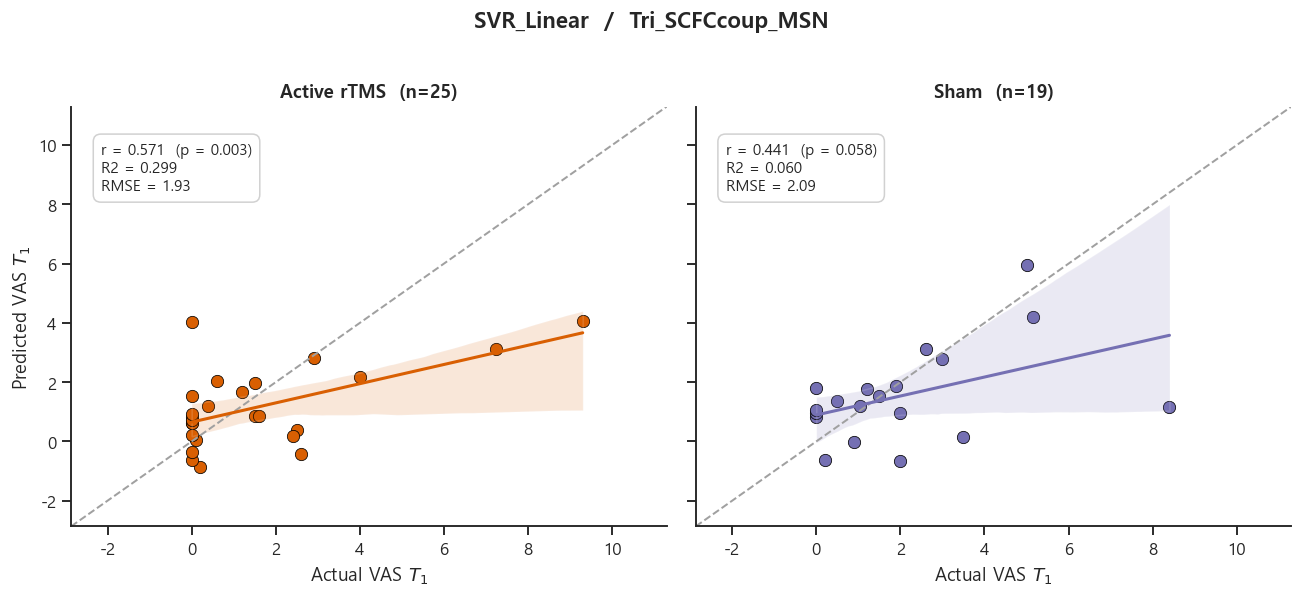

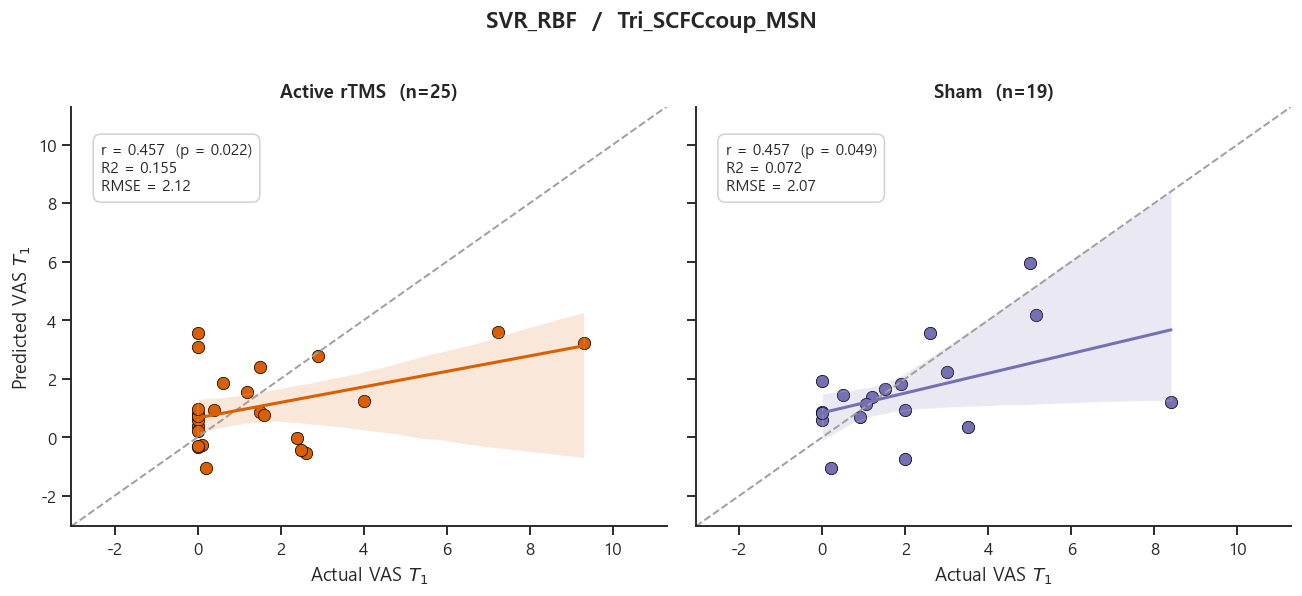

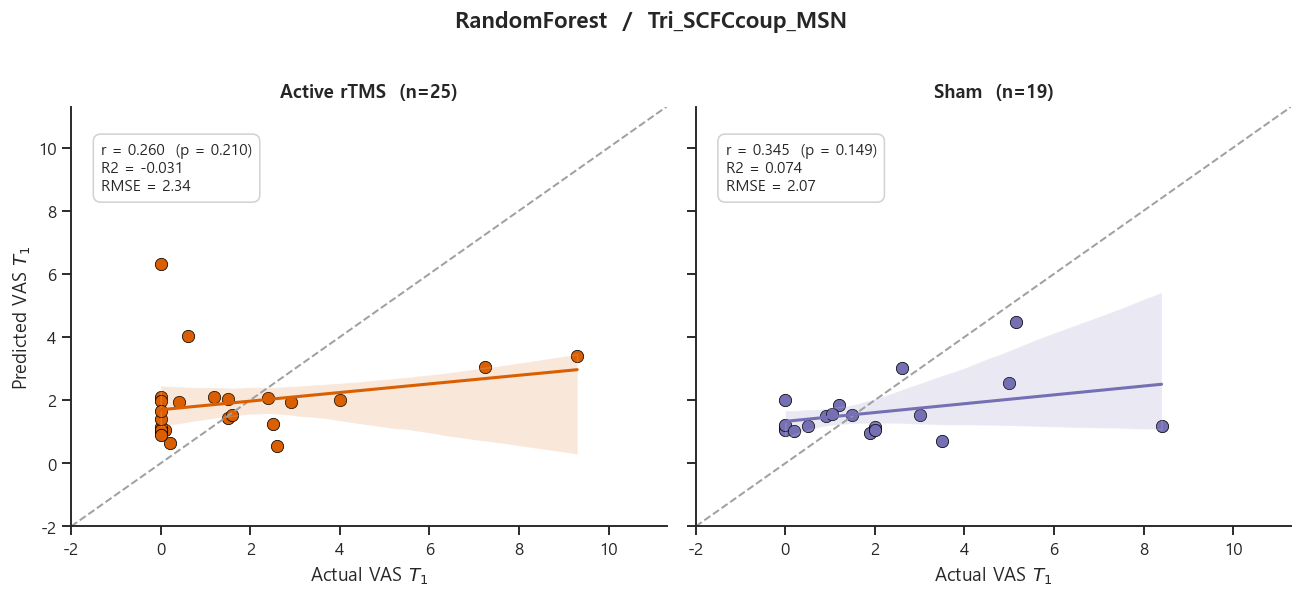

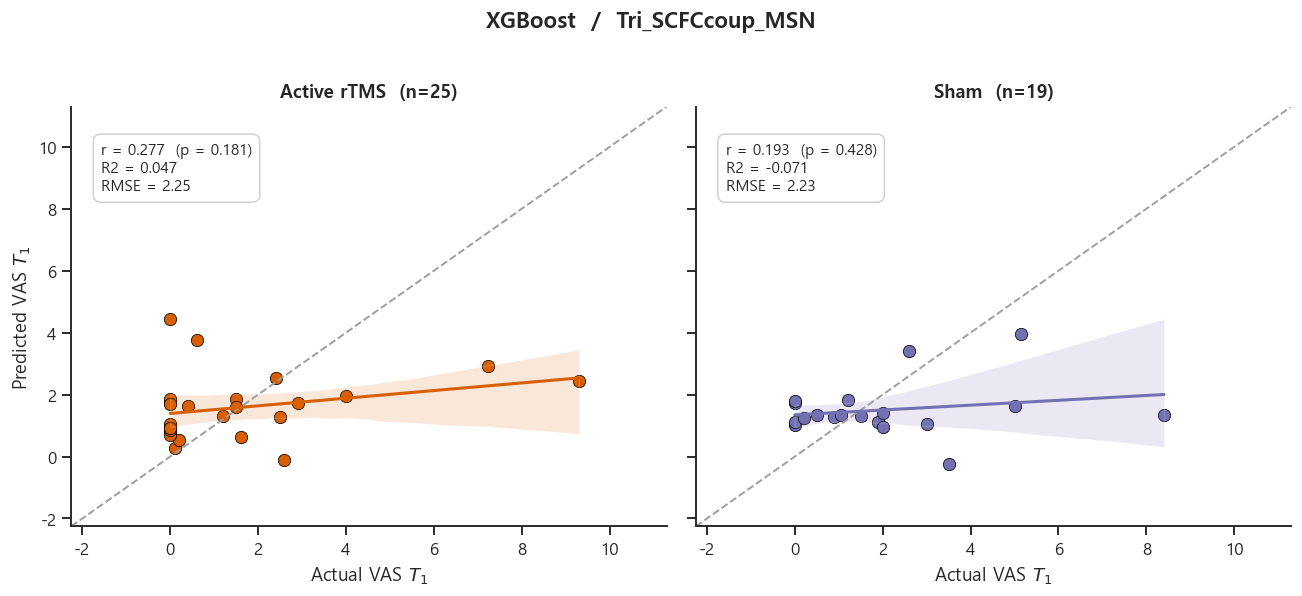

In [9]:
# ==========================================================
# 9. 산점도 — Active rTMS vs Sham 분리 (기존 멀티모달 노트북 8번 셀과 동일한 형식)
#    LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = ['SCFC_Coup_PCA3', 'MSN_PCA3', 'Tri_SCFCcoup_MSN']   # 줄이려면 여기서 빼기
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [10]:
# ==========================================================
# 10. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#     (그림에 찍힌 값과 같은 숫자다. 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

# --- 넓은 표: 행 = 피처셋 x 모델, 열 = Active/Sham x 지표 ---
wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

# --- 좁은 표: RMSE와 r만, 두 군을 나란히 ---
print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

# --- 군별로 가장 좋았던 조합 ---
print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                             Active                        Sham         \
                                    RMSE     R2      r      p   RMSE     R2   
Data Type        Model                                                        
Clinical_ONLY    LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
                 ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
                 SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
                 SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
                 RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
                 XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
SCFC_Coup_PCA3   LinearRegression  1.787  0.400  0.633  0.001  1.935  0.191   
                 ElasticNet        1.831  0.370  0.609  0.001  1.935  0.191   
                 SVR_Linear        1.785  0.402  0.635  0.001  1.872  0.243   
                 SVR_RBF           1.890  0.329  0.611  0.001  1.939  0.188   
                 RandomForest      2.235  0.063  0.345  0.091  2.059  0.084   
                 XGBoost           2.014  0.238  0.489  0.013  2.197 -0.043   
MSN_PCA3         LinearRegression  2.053  0.208  0.473  0.017  2.032  0.108   
                 ElasticNet        2.041  0.218  0.473  0.017  1.979  0.154   
                 SVR_Linear        2.017  0.236  0.511  0.009  1.986  0.148   
                 SVR_RBF           2.044  0.215  0.486  0.014  1.987  0.147   
                 RandomForest      2.461 -0.137  0.206  0.323  2.062  0.082   
                 XGBoost           2.356 -0.042  0.193  0.354  2.189 -0.035   
Tri_SCFCcoup_MSN LinearRegression  1.787  0.401  0.634  0.001  1.999  0.137   
                 ElasticNet        1.843  0.362  0.605  0.001  1.938  0.189   
                 SVR_Linear        1.932  0.299  0.571  0.003  2.086  0.060   
                 SVR_RBF           2.122  0.155  0.457  0.022  2.073  0.072   
                 RandomForest      2.343 -0.031  0.260  0.210  2.070  0.074   
                 XGBoost           2.253  0.047  0.277  0.181  2.226 -0.071   

Group                                            
                                       r      p  
Data Type        Model                           
Clinical_ONLY    LinearRegression  0.402  0.088  
                 ElasticNet        0.402  0.088  
                 SVR_Linear        0.400  0.090  
                 SVR_RBF           0.329  0.170  
                 RandomForest      0.302  0.209  
                 XGBoost           0.307  0.202  
SCFC_Coup_PCA3   LinearRegression  0.463  0.046  
                 ElasticNet        0.461  0.047  
                 SVR_Linear        0.512  0.025  
                 SVR_RBF           0.465  0.045  
                 RandomForest      0.360  0.130  
                 XGBoost           0.184  0.452  
MSN_PCA3         LinearRegression  0.431  0.065  
                 ElasticNet        0.427  0.068  
                 SVR_Linear        0.439  0.060  
                 SVR_RBF           0.439  0.060  
                 RandomForest      0.372  0.117  
                 XGBoost           0.183  0.452  
Tri_SCFCcoup_MSN LinearRegression  0.475  0.040  
                 ElasticNet        0.474  0.041  
                 SVR_Linear        0.441  0.058  
                 SVR_RBF           0.457  0.049  
                 RandomForest      0.345  0.149  
                 XGBoost           0.193  0.428


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type        Model                                                        
Clinical_ONLY    LinearRegression        2.004      1.989     0.507   0.402   
                 ElasticNet              2.003      1.988     0.507   0.402   
                 SVR_Linear              2.055      2.022     0.475   0.400   
                 SVR_RBF                 2.291      2.095     0.358   0.329   
                 RandomForest            2.261      2.118     0.356   0.302   
                 XGBoost                 2.341      2.089     0.319   0.307   
SCFC_Coup_PCA3   LinearRegression        1.787      1.935     0.633   0.463   
                 ElasticNet              1.831      1.935     0.609   0.461   
                 SVR_Linear              1.785      1.872     0.635   0.512   
                 SVR_RBF                 1.890      1.939     0.611   0.465   
                 RandomForest            2.235      2.059     0.345   0.360   
                 XGBoost                 2.014      2.197     0.489   0.184   
MSN_PCA3         LinearRegression        2.053      2.032     0.473   0.431   
                 ElasticNet              2.041      1.979     0.473   0.427   
                 SVR_Linear              2.017      1.986     0.511   0.439   
                 SVR_RBF                 2.044      1.987     0.486   0.439   
                 RandomForest            2.461      2.062     0.206   0.372   
                 XGBoost                 2.356      2.189     0.193   0.183   
Tri_SCFCcoup_MSN LinearRegression        1.787      1.999     0.634   0.475   
                 ElasticNet              1.843      1.938     0.605   0.474   
                 SVR_Linear              1.932      2.086     0.571   0.441   
                 SVR_RBF                 2.122      2.073     0.457   0.457   
                 RandomForest            2.343      2.070     0.260   0.345   
                 XGBoost                 2.253      2.226     0.277   0.193   

                                   RMSE_diff  
Data Type        Model                        
Clinical_ONLY    LinearRegression      0.015  
                 ElasticNet            0.015  
                 SVR_Linear            0.033  
                 SVR_RBF               0.196  
                 RandomForest          0.143  
                 XGBoost               0.252  
SCFC_Coup_PCA3   LinearRegression     -0.148  
                 ElasticNet           -0.104  
                 SVR_Linear           -0.088  
                 SVR_RBF              -0.049  
                 RandomForest          0.176  
                 XGBoost              -0.183  
MSN_PCA3         LinearRegression      0.021  
                 ElasticNet            0.063  
                 SVR_Linear            0.031  
                 SVR_RBF               0.057  
                 RandomForest          0.399  
                 XGBoost               0.167  
Tri_SCFCcoup_MSN LinearRegression     -0.213  
                 ElasticNet           -0.095  
                 SVR_Linear           -0.153  
                 SVR_RBF               0.049  
                 RandomForest          0.273  
                 XGBoost               0.026


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,SCFC_Coup_PCA3,SVR_Linear,1.785,0.402,0.635,0.001
1,Tri_SCFCcoup_MSN,LinearRegression,1.787,0.401,0.634,0.001
2,SCFC_Coup_PCA3,LinearRegression,1.787,0.400,0.633,0.001
3,SCFC_Coup_PCA3,ElasticNet,1.831,0.370,0.609,0.001
4,Tri_SCFCcoup_MSN,ElasticNet,1.843,0.362,0.605,0.001



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,SCFC_Coup_PCA3,SVR_Linear,1.872,0.243,0.512,0.025
1,SCFC_Coup_PCA3,ElasticNet,1.935,0.191,0.461,0.047
2,SCFC_Coup_PCA3,LinearRegression,1.935,0.191,0.463,0.046
3,Tri_SCFCcoup_MSN,ElasticNet,1.938,0.189,0.474,0.041
4,SCFC_Coup_PCA3,SVR_RBF,1.939,0.188,0.465,0.045
